
ADABOOST REGRESSOR
Mean squared error = 1.18
Explained variance score = 0.47


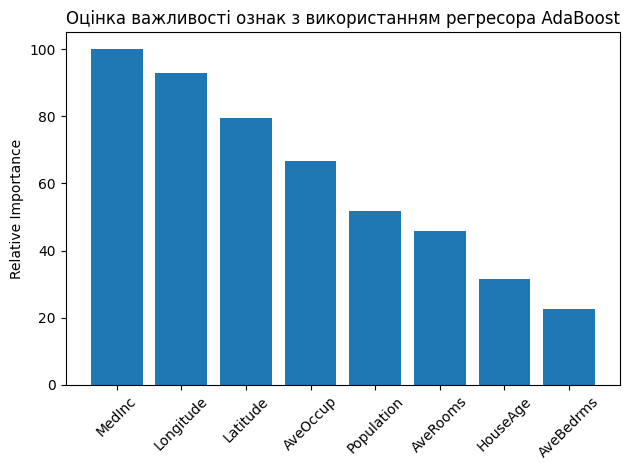

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, explained_variance_score
from sklearn.utils import shuffle
# Використовуємо інший датасет замість застарілого boston_housing
from sklearn.datasets import fetch_california_housing 

# Завантаження даних із цінами на нерухомість
housing_data = fetch_california_housing()

# Перемішування даних
X, y = shuffle(housing_data.data, housing_data.target, random_state=7)

# Розбиття даних на навчальний та тестовий набори
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

# Модель на основі регресора AdaBoost
regressor = AdaBoostRegressor(DecisionTreeRegressor(max_depth=4), n_estimators=400, random_state=7)
regressor.fit(X_train, y_train)

# Обчислення показників ефективності регресора AdaBoost
y_pred = regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)

print("\nADABOOST REGRESSOR")
print("Mean squared error =", round(mse, 2))
print("Explained variance score =", round(evs, 2))

# Вилучення важливості ознак
feature_importances = regressor.feature_importances_
feature_names = housing_data.feature_names

# Нормалізація значень важливості ознак
feature_importances = 100.0 * (feature_importances / max(feature_importances))

# Сортування та перестановка значень
index_sorted = np.flipud(np.argsort(feature_importances))

# Розміщення міток уздовж осі Х
pos = np.arange(index_sorted.shape[0]) + 0.5

# Побудова стовпчастої діаграми
plt.figure()
plt.bar(pos, feature_importances[index_sorted], align='center')
plt.xticks(pos, np.array(feature_names)[index_sorted], rotation=45)
plt.ylabel('Relative Importance')
plt.title('Оцінка важливості ознак з використанням регресора AdaBoost')
plt.tight_layout()
plt.show()